In [1]:
from configs import *


In [2]:
def simulate(bird, world, n_episodes, time_steps, train=False):
    """ Simulate bird, possible episodic SARSA. """
    # Episodic loop
    for _ in range(n_episodes):

        # Random initial state, first bird action
        x, y, z = world.random_state_coords()
        state  = world.state_to_index(x, y, z)
        action = bird.policy(state)

        # Time-step loop
        for t in range(time_steps):
            # Transition state, get bird action and reward
            next_state  = world.transition(state, action)
            next_action = bird.policy(next_state)
            reward      = world.reward(next_state)

            # Learning
            if train: bird.update(state, action, reward, next_state, next_action)

            # Update current state and action
            state, action  = next_state, next_action

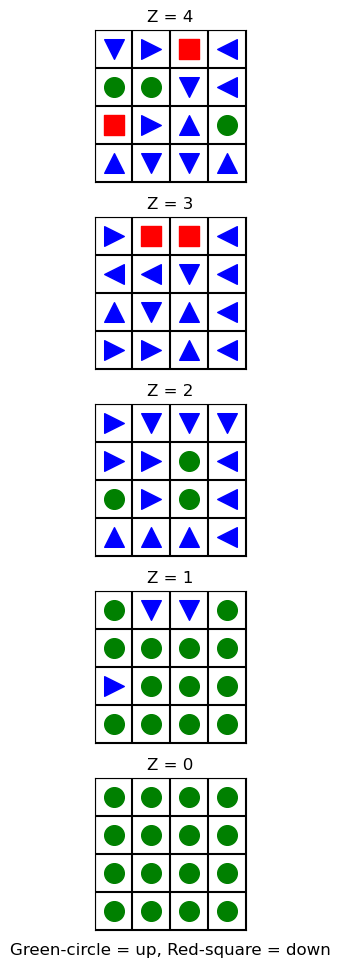

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create environment
world = World(x_size=4, y_size=4, z_size=5, wind=[0.0, 0.0, 0.0])

# Create the bird
bird = ShittyBird(
    n_states=world.n_states,
    n_actions=world.n_actions,
    n_planning=5,
    update_type='SARSA'
)
bird.init_transition_model(world)

# Save the initial q_values
q_values_prior = bird.action_values.flatten()

# Train the bird
simulate(bird, world, n_episodes=1000, time_steps=1000, train=True)

# Save the final q_values
q_values_post = bird.action_values.flatten()

# Plot the policy
plot_action_values(bird, world)